In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

# Base sintética com 10 amostras desbalanceadas (8 da classe 0 e 2 da classe 1)
X_exemplo = np.array([
    [1.0, 2.0], [1.5, 1.8], [2.0, 2.5], [2.5, 3.0], [3.0, 2.8],
    [3.5, 3.2], [4.0, 4.0], [4.5, 3.8], [8.0, 8.5], [9.0, 9.2]
])
y_exemplo = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

# Divisão (70% treino, 30% teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_exemplo,
    y_exemplo,
    test_size=0.30,
    random_state=42,
    stratify=y_exemplo
)

print(f"Total original: {len(y_exemplo)} amostras | Classes: {np.bincount(y_exemplo)}")
print(f"Total treino: {len(y_treino)} amostras | Classes: {np.bincount(y_treino)}")
print(f"Total teste: {len(y_teste)} amostras | Classes: {np.bincount(y_teste)}")

Total original: 10 amostras | Classes: [8 2]
Total treino: 7 amostras | Classes: [6 1]
Total teste: 3 amostras | Classes: [2 1]


In [2]:
# Cálculo manual de métricas com numpy
def extrair_matriz_confusao(y_real: np.ndarray, y_pred: np.ndarray):
    """Extrai VP, VN, FP e FN a partir dos vetores de rótulos."""
    vp = np.sum((y_real == 1) & (y_pred == 1))
    vn = np.sum((y_real == 0) & (y_pred == 0))
    fp = np.sum((y_real == 0) & (y_pred == 1))
    fn = np.sum((y_real == 1) & (y_pred == 0))
    return int(vp), int(vn), int(fp), int(fn)


def calcular_metricas_numpy(y_real: np.ndarray, y_pred: np.ndarray):
    """Calcula acurácia, precisão, recall, especificidade e F1-Score."""

    vp, vn, fp, fn = extrair_matriz_confusao(y_real, y_pred)
    total = vp + vn + fp + fn

    acuracia = (vp + vn) / total if total > 0 else 0.0
    precisao = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    recall = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    especificidade = vn / (vn + fp) if (vn + fp) > 0 else 0.0

    # F1-Score: média harmônica entre precisão e recall
    if (precisao + recall) > 0:
        f1 = 2 * (precisao * recall) / (precisao + recall)
    else:
        f1 = 0.0

    return {
        "VP": vp, "VN": vn, "FP": fp, "FN": fn,
        "Acuracia": acuracia,
        "Precisao": precisao,
        "Recall": recall,
        "Especificidade": especificidade,
        "F1_Score": f1,
    }


# Teste com valores sintéticos
y_teste_demo = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])
y_pred_demo  = np.array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1])

res = calcular_metricas_numpy(y_teste_demo, y_pred_demo)
for metrica, valor in res.items():
    print(f"{metrica:<15}: {valor}")

VP             : 3
VN             : 7
FP             : 1
FN             : 1
Acuracia       : 0.8333333333333334
Precisao       : 0.75
Recall         : 0.75
Especificidade : 0.875
F1_Score       : 0.75


Teste com dataset real

In [9]:
#Load_breast_cancer (Scikit-learn)
#1. Carregar dados nativos (retorna diretamente a tupla X e y)
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
nomes_classes = ["malignant", "benign"]

#2. Divisão (70% Treino 30% teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Total de instancias na base: {len(y)}")
print(f"Amostras de Treino: {len(y_treino)} (Maligno {np.sum(y_treino==0)}, Benigno: {np.sum(y_treino==1)})")
print(f"Amostras de teste: {len(y_teste)} (Maligno: {np.sum(y_teste==0)}, Benigno: {np.sum(y_teste)})")


Total de instancias na base: 569
Amostras de Treino: 398 (Maligno 148, Benigno: 250)
Amostras de teste: 171 (Maligno: 64, Benigno: 107)


In [10]:
#Treinamento modelos prontos do scikit-learn

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier

#Instanciando e treinando (.fit) direto de daca modelo
modelos = {
    "Dumy (majoritário)": DummyClassifier(strategy="most_frequent").fit(X_treino, y_treino),
    "Perceptron (Sklearn)": Perceptron(max_iter=1000, random_state=42).fit(X_treino, y_treino),
    "KNN K=5": KNeighborsClassifier(n_neighbors=5).fit(X_treino, y_treino)
}

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 76)
print(f"{'modelo':<24} | {'Acurácia':<10} | {'Precisão':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("=" * 76)

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_teste)
    acc = accuracy_score(y_teste, y_pred)
    prec = precision_score(y_teste, y_pred, zero_division=0)
    rec = recall_score(y_teste, y_pred, zero_division=0)
    f1 = f1_score(y_teste, y_pred, zero_division=0)
    print(f"{nome:<24} | {acc:<10.2%} | {prec:<10.2%} | {rec:<10.2%} | {f1:<10.4f}")

print("=" * 76)


modelo                   | Acurácia   | Precisão   | Recall     | F1-Score  
Dumy (majoritário)       | 62.57%     | 62.57%     | 100.00%    | 0.7698    
Perceptron (Sklearn)     | 63.74%     | 97.87%     | 42.99%     | 0.5974    
KNN K=5                  | 92.40%     | 93.52%     | 94.39%     | 0.9395    


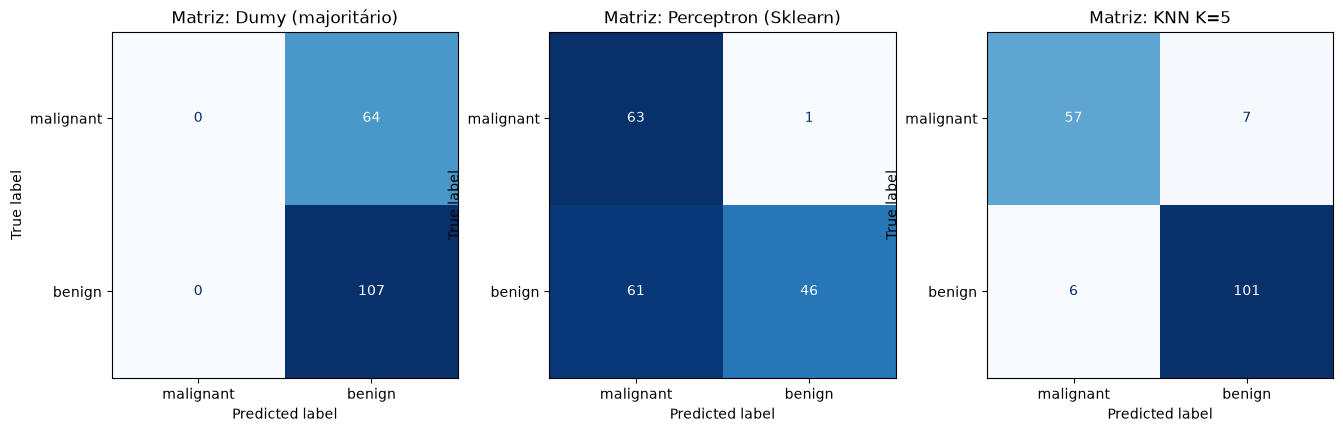

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, (nome, modelo) in enumerate(modelos.items()):
    ConfusionMatrixDisplay.from_estimator(
        modelo, 
        X_teste,
        y_teste,
        display_labels=nomes_classes,
        cmap="Blues",
        ax=axes[i],
        colorbar=False
    )
    axes[i].set_title(f"Matriz: {nome}")
    axes[i].grid(False)

    #Os graficos mostram onde cada modelo acertou (matriz de confusão)
    #Na vertical representa o diagnostico verdadeiro
    #No caso do Dumy jogou tudo como benigno
    #No perceptron errou 
    #KNN foi mais preciso nas análises
    #Este grafico mostra quando vc tem várias classes


In [14]:
from sklearn.metrics import classification_report

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_teste)
    print(f"\n{'=' * 65}")
    print(f"Relatorios de Desempenho: {nome}")
    print(f"\n{'=' * 65}")
    print(classification_report(y_teste, y_pred, target_names=nomes_classes, zero_division=0))


Relatorios de Desempenho: Dumy (majoritário)

              precision    recall  f1-score   support

   malignant       0.00      0.00      0.00        64
      benign       0.63      1.00      0.77       107

    accuracy                           0.63       171
   macro avg       0.31      0.50      0.38       171
weighted avg       0.39      0.63      0.48       171


Relatorios de Desempenho: Perceptron (Sklearn)

              precision    recall  f1-score   support

   malignant       0.51      0.98      0.67        64
      benign       0.98      0.43      0.60       107

    accuracy                           0.64       171
   macro avg       0.74      0.71      0.63       171
weighted avg       0.80      0.64      0.62       171


Relatorios de Desempenho: KNN K=5

              precision    recall  f1-score   support

   malignant       0.90      0.89      0.90        64
      benign       0.94      0.94      0.94       107

    accuracy                           0.92       